# W05 · PPO：策略梯度与近端优化

> 阶段一第 5 周。W03–W04 的路线是「先学价值，再从中导出动作」；
> 本周换一条更直接的路线：**直接参数化策略** $\pi_\theta(a|s)$，用梯度上升优化回报。
> PPO 是当前机器人 RL 事实上的默认算法（Isaac Lab / MotrixLab 的示例大多用它）。

## 学习目标

1. 写出策略梯度定理，并解释 REINFORCE 的方差问题与 advantage 的作用；
2. 推导 PPO 的 clipped 目标函数，说明它如何把「步子别迈太大」变成一行代码；
3. 说清 PPO 是 on-policy 的含义及其对样本效率的影响；
4. 用 SB3 PPO 训练 CartPole，读懂 `n_steps` / `batch_size` / `clip_range` / `ent_coef` 四个核心超参；
5. 通过对比实验感受 `clip_range` 的影响。

**先修要求**：W01（回报/价值）、W04（函数逼近）。预计用时 3 小时。

## 1. 策略梯度：直接优化「动作分布」

价值方法里策略是间接的（$\arg\max_a Q$）；策略梯度方法直接学一个带参分布
$\pi_\theta(a|s)$（离散动作输出 softmax，连续动作输出高斯的均值/方差）。
目标函数是期望回报 $J(\theta) = \mathbb{E}_{\pi_\theta}[G_0]$。

**策略梯度定理**：

$$\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta}\Big[\nabla_\theta \log \pi_\theta(a|s)\, Q^{\pi}(s,a)\Big]$$

直觉读法：$\nabla \log \pi_\theta(a|s)$ 是「让这个动作更可能」的方向，
乘上 $Q^{\pi}(s,a)$——**好动作加大概率，坏动作减小概率**。就这么朴素。

**REINFORCE** 用整条回合的回报 $G_t$ 代替 $Q^{\pi}$：无需模型、无需价值网络，但方差极大
（一条轨迹里所有动作共享同一个回报，好坏动作分不清）。

**降低方差的标配**——用 **advantage** 替代回报：

$$A^{\pi}(s,a) = Q^{\pi}(s,a) - V^{\pi}(s)$$

含义：「这个动作比该状态下的平均水平好多少」。减掉基线 $V^\pi$ 不改变梯度的期望
（数学上可证明），却大幅压低方差。为此需要一个**价值网络（critic）**来估计 $V^\pi$，
策略网络叫 **actor**——这就是 **Actor-Critic** 架构。PPO 用的是 GAE（广义优势估计）
来进一步权衡偏差与方差。

## 2. 从策略梯度到 PPO：约束「步子大小」

朴素策略梯度的痛点：**步长敏感**。on-policy 数据由当前策略产生，
一次过大的更新把策略改得面目全非 → 旧数据失效 → 性能崩塌（RL 里叫 policy collapse）。

TRPO 用 KL 散度硬约束新旧策略差异，但实现复杂（共轭梯度 + 线搜索）。
PPO 的天才之处在于用一个**截断比率**达到类似效果。定义概率比
$r_t(\theta) = \dfrac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}$（新策略相对旧策略的「动作概率变化倍数」），
PPO 的目标是：

$$L^{CLIP}(\theta) = \mathbb{E}_t\Big[\min\big(r_t(\theta)\,\hat{A}_t,\; \text{clip}(r_t(\theta),\, 1-\epsilon,\, 1+\epsilon)\,\hat{A}_t\big)\Big]$$

读法：

- $r_t$ 落在 $[1-\epsilon, 1+\epsilon]$ 内：正常按优势加权更新；
- 一旦新旧策略偏差超过 $\epsilon$（典型 0.2）：超出部分的梯度被截断为 0——**不允许单步更新改变策略太多**；
- 取 $\min$ 保证这是真实目标的下界（悲观估计），防止「看起来在改进其实在崩」。

类比：like 学车时教练限制你「每次方向盘最多打 15°」——可以慢，但不会翻。

**on-policy 的代价**：PPO 每批数据只用一次就扔（策略一变旧数据失效），样本效率低于 off-policy。
换来的是稳定性与实现简洁。工程上靠**向量化环境并行采样**弥补（W07 细讲）。

## 3. SB3 PPO 上手：CartPole 3 万步

评估（20 回合）: 500.0 ± 0.0  （满分 500）


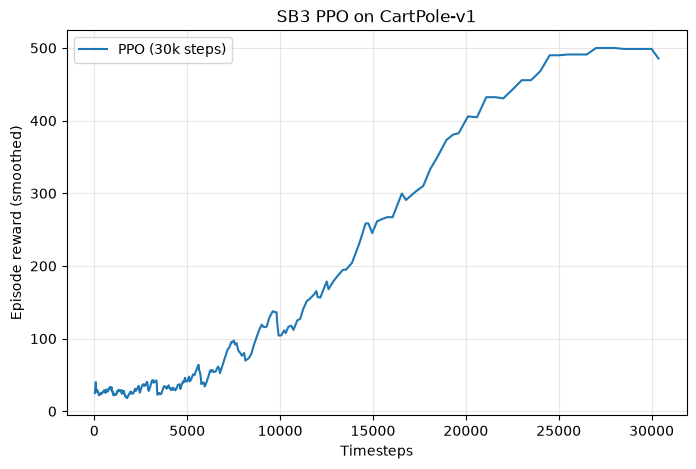

In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from robot_rl_learn.common.paths import make_run_dir
from robot_rl_learn.phase1_sb3.train import evaluate
from robot_rl_learn.phase1_sb3.plots import plot_learning_curve

run_dir = make_run_dir("w05_cartpole_ppo")
# Monitor 显式落盘（runs/ 目录约定），供学习曲线读取
train_env = Monitor(gym.make("CartPole-v1"), filename=str(run_dir / "train"))

model = PPO("MlpPolicy", train_env, seed=0, verbose=0, device="cpu")
model.learn(total_timesteps=30_000)

mean_r, std_r = evaluate(model, "CartPole-v1", n_episodes=20)
print(f"评估（20 回合）: {mean_r:.1f} ± {std_r:.1f}  （满分 500）")

plot_learning_curve({"PPO (30k steps)": run_dir}, window=10)
plt.title("SB3 PPO on CartPole-v1")
plt.show()

## 4. 读懂 PPO 的核心超参

SB3 的 PPO 有一串默认值，理解它们的**相互关系**比记住数值重要：

In [2]:
for name in ["n_steps", "batch_size", "n_epochs", "gamma", "gae_lambda", "ent_coef", "learning_rate"]:
    print(f"{name:>14} = {getattr(model, name)}")
print(f"{'clip_range':>14} = {model.clip_range(1.0):.2f}  (SB3 存的是 schedule，传入进度 1.0 取当前值)")

print()
print("数据流关系：")
print(f"  每次 rollout 收集 n_steps × n_envs = {model.n_steps} × 1 = {model.n_steps} 条转移")
print(f"  然后把这些数据打乱，按 batch_size={model.batch_size} 切 mini-batch，")
print(f"  重复训练 n_epochs={model.n_epochs} 轮 → 每批数据实际被复用了 {model.n_epochs} 次")
print(f"  （所以 PPO 严格说是'近 on-policy'：一轮内策略已更新，靠 clip 兜住偏差）")

       n_steps = 2048
    batch_size = 64
      n_epochs = 10
         gamma = 0.99
    gae_lambda = 0.95
      ent_coef = 0.0
 learning_rate = 0.0003
    clip_range = 0.20  (SB3 存的是 schedule，传入进度 1.0 取当前值)

数据流关系：
  每次 rollout 收集 n_steps × n_envs = 2048 × 1 = 2048 条转移
  然后把这些数据打乱，按 batch_size=64 切 mini-batch，
  重复训练 n_epochs=10 轮 → 每批数据实际被复用了 10 次
  （所以 PPO 严格说是'近 on-policy'：一轮内策略已更新，靠 clip 兜住偏差）


超参直觉速查：

| 超参 | 作用 | 调大 / 调小的典型后果 |
|---|---|---|
| `n_steps` | 每次 rollout 收集的步数 | 大：优势估计更准、更新更稳，但迭代变慢 |
| `batch_size` | mini-batch 大小 | 大：梯度噪声小；必须 ≤ `n_steps × n_envs` |
| `clip_range` $\epsilon$ | 新旧策略最大偏离 | 大：学得快但可能崩；小：稳但慢 |
| `ent_coef` | 熵奖励系数 | 大：鼓励探索（动作更随机）；太大会不收敛 |
| `gae_lambda` | GAE 偏差-方差权衡 | 接近 1 方差大偏差小；接近 0 反之 |

## 5. 对比实验：`clip_range` 的直觉验证

理论说 $\epsilon$ 太小会拖慢学习。跑两组实验验证（各 2 万步）：

clip=0.1 完成


clip=0.3 完成


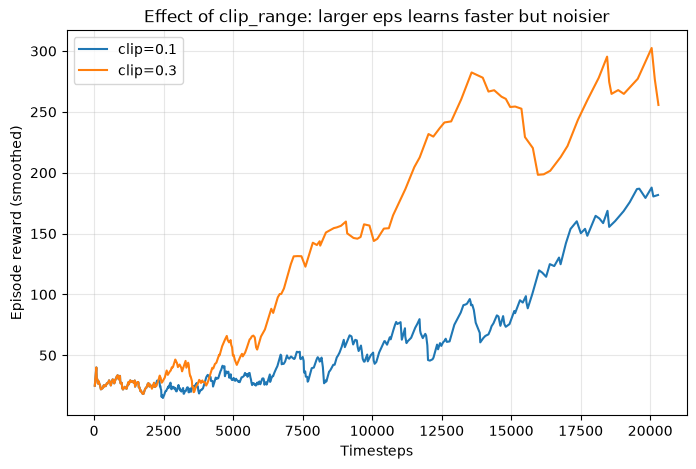

In [3]:
runs = {}
for eps_tag, eps in [("clip=0.1", 0.1), ("clip=0.3", 0.3)]:
    d = make_run_dir(f"w05_cartpole_ppo_clip{eps}")
    env = Monitor(gym.make("CartPole-v1"), filename=str(d / "train"))
    m = PPO("MlpPolicy", env, seed=0, verbose=0, device="cpu", clip_range=eps)
    m.learn(total_timesteps=20_000)
    runs[eps_tag] = d
    print(f"{eps_tag} 完成")

plot_learning_curve(runs, window=10)
plt.title("Effect of clip_range: larger eps learns faster but noisier")
plt.show()

**典型观察**：`clip=0.3` 早期上升更快，但曲线抖动更大；`clip=0.1` 更平滑保守。
在 CartPole 这种简单环境差异不大，但在 W06 的连续控制与后续机器人任务里，
`clip_range` 过大是「训练到一半突然崩塌」的常见元凶——那时记得回来看这一节。

---

## ✏️ 练习

**练习 1（★，10 分钟）——超参关系推理**
若把 `n_envs` 提到 8、`n_steps=256`，每轮 rollout 有多少条转移？若 `batch_size=64`，
每轮做多少次参数更新（提示：× `n_epochs`）？用代码算出来。
**交付物**：计算 cell + 两行说明。

**练习 2（★★，25 分钟）——`n_steps` 样本效率实验**
对比 `n_steps=64` 与 `n_steps=2048`（batch_size 保持 64，各 3 万步）在 CartPole 上的学习曲线。
**交付物**：对比图 + 两句话：哪条早期上升快？用「on-policy 数据新鲜度」解释。

**练习 3（★★，20 分钟）——熵系数实验**
对比 `ent_coef=0.0` 与 `ent_coef=0.05`（各 2 万步）。
**交付物**：对比图 + 一句话说明熵奖励在什么类型的任务里最值得调大（提示：稀疏奖励/易陷局部最优）。

**练习 4（★★★，35 分钟）——读原论文**
读 PPO 论文（[arXiv:1707.06347](https://arxiv.org/abs/1707.06347)）的摘要、第 3 节与图 1，
按「问题-方法-实验-局限」四段式写 200 字笔记。
**交付物**：markdown 笔记（写进 `journal/` 更佳）。

---

<details>
<summary>参考答案（做完再点开）</summary>

**练习 1**：每轮 rollout 收集 $256 \times 8 = 2048$ 条转移；
每轮更新次数 = `n_epochs` ×（2048 / 64）= 10 × 32 = **320 次梯度更新**。
可见 PPO 一轮 rollout 会复用数据多轮——clip 机制正是为了让这种复用不至于跑偏。

**练习 2**：`n_steps=64` 每 64 步就更新一次策略，**迭代频率高、早期上升更快**，
但优势估计基于很短轨迹、偏差大，后期天花板可能略低；
`n_steps=2048` 用陈旧数据做 10 轮更新的时间占比更高（数据新鲜度差），收敛更慢但更稳。
on-policy 的本质：数据保质期短，`n_steps` 就是「一次囤多少货」的权衡。

**练习 3**：`ent_coef=0.05` 的动作分布保持更宽的探索，CartPole 上差异小（奖励稠密）。
熵奖励最值得调大的场景：**稀疏奖励 + 多峰奖励地形**（如导航迷宫），
没有熵正则策略会过早坍缩到第一个次优解。

**练习 4**（要点提示）：问题——TRPO 可靠但实现复杂、不兼容 RNN/参数共享；
方法——clipped 替代目标，一阶优化即可，代码 ~10 行改动；
实验——MuJoCo 连续控制与 Atari 上达到或超过 TRPO/ACER 且调参更宽容；
局限——仍是 on-policy 样本效率低（后续 SAC 解决），clip 并非严格的信任域
（有理论工作指出其约束并不完备）。

</details>

---

## 延伸阅读

- 论文：[Schulman et al. 2017, Proximal Policy Optimization Algorithms](https://arxiv.org/abs/1707.06347)；前身 [TRPO (2015)](https://arxiv.org/abs/1502.05477)
- [SB3 文档：PPO](https://stable-baselines3.readthedocs.io/en/master/modules/ppo.html)
- 经典解读博客：[Spinning Up in Deep RL — PPO](https://spinningup.openai.com/en/latest/algorithms/ppo.html)（OpenAI 官方教程，公式推导详尽）
- [CleanRL 的 PPO 单文件实现](https://github.com/vwxyzjn/cleanrl)（`cleanrl/ppo.py`，强烈建议精读）
- Sutton & Barto 第 13 章（Policy Gradient Methods）。